# Lognormal sample explorer

This notebook shows how the distribution of `random.lognormvariate(mu, sigma)` changes as `mu` and `sigma` change. The red vertical line marks a threshold that you can adjust interactively.

The default threshold starts at `1.5`.

In [37]:
%pip install numpy matplotlib

161994.56s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.7 MB/s eta 0:00:00a 0:00:01
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 6.9 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 23.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 21.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.1/64.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 44.0 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
Note: you may need to restart the kernel to use updated packages.


In [38]:
import random
import numpy as np
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider, IntSlider
import math
import matplotlib.pyplot as plt

In [2]:
def plot_lognormal(mu, sigma, threshold, n_samples=50000):
    rng = random.Random()
    samples = [rng.lognormvariate(mu, sigma) for _ in range(n_samples)]
    above_threshold = sum(1 for x in samples if x > threshold) / len(samples)

    fig = go.Figure()
    fig.add_trace(go.Histogram(
        x=samples,
        nbinsx=80,
        opacity=0.8,
        name='lognormal samples'
    ))

    fig.add_vline(
        x=threshold,
        line_color='red',
        line_width=3,
        line_dash='solid',
        annotation_text=f'threshold = {threshold}',
        annotation_position='top left',
    )

    fig.update_layout(
        title=f'Lognormal distribution: mu={mu}, sigma={sigma} | proportion > threshold = {above_threshold:.2%}',
        xaxis_title='x',
        yaxis_title='count',
        bargap=0.05,
        template='plotly_white',
        width=900,
        height=600
    )

    fig.show()

In [3]:
@interact(
    mu=FloatSlider(value=0.0, min=-2.0, max=3.0, step=0.1, description='mu'),
    sigma=FloatSlider(value=0.5, min=0.1, max=2.5, step=0.1, description='sigma'),
    threshold=FloatSlider(value=1.5, min=0.1, max=10.0, step=0.1, description='threshold'),
    n_samples=IntSlider(value=50000, min=1000, max=200000, step=1000, description='samples')
)
def update(mu, sigma, threshold, n_samples):
    plot_lognormal(mu, sigma, threshold, n_samples)

interactive(children=(FloatSlider(value=0.0, description='mu', max=3.0, min=-2.0), FloatSlider(value=0.5, desc…

In [11]:
random.uniform(1, 5)

4.207114224237889

In [27]:
def plot_rand(A, threshold, n_samples=500):
    """Draw samples from a linearly increasing distribution on [0, 1]."""
    skew = max(0.0, float(A))
    samples = []
    for _ in range(n_samples):
        uniform_sample = random.random()
        scaled_sample = uniform_sample * (1.0 + skew / 2.0)
        sample = (2.0 * scaled_sample) / (1.0 + np.sqrt(1.0 + 2.0 * skew * scaled_sample))
        samples.append(sample)
    above_threshold = sum(1 for x in samples if x > threshold) / len(samples)

    fig = go.Figure()
    fig.add_trace(go.Histogram(
        x=samples,
        nbinsx=80,
        opacity=0.8,
        name='linearly skewed samples'
    ))

    fig.add_vline(
        x=threshold,
        line_color='red',
        line_width=3,
        line_dash='solid',
        annotation_text=f'threshold = {threshold}',
        annotation_position='top left',
    )

    fig.update_layout(
        title=f'Linearly skewed distribution: A={skew:.1f} | proportion > threshold = {above_threshold:.2%}',
        xaxis_title='x',
        yaxis_title='count',
        bargap=0.05,
        template='plotly_white',
        xaxis=dict(range=[0, 1]),
        width=900,
        height=600
    )

    fig.show()

In [28]:
@interact(
    A=FloatSlider(value=1.0, min=0.0, max=10.0, step=0.1, description='skew'),
    threshold=FloatSlider(value=0.4, min=0.0, max=1.0, step=0.01, description='threshold'),
    n_samples=IntSlider(value=20000, min=10, max=200000, step=10, description='samples')
)
def update(A, threshold, n_samples):
    plot_rand(A, threshold, n_samples)

interactive(children=(FloatSlider(value=1.0, description='skew', max=10.0), FloatSlider(value=0.4, description…

In [ ]:
def plot_exponential():
    age = np.arange(0, 100, 1)
    scaling = 100#9.95
    #prob_death_log = abs(1.0 + np.log(0.27+age / scaling))/(np.log(scaling)+1)
    #prob_death_cdf =  np.exp(age / scaling)/(np.exp(100 / scaling)-1 )
    prob_death_exp =  np.exp(  (age/scaling - 1) * np.sqrt(scaling) )#/np.exp(scaling)
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)

    #ax.plot(age, prob_death_log, label='Logarithmic')
    #ax.plot(age, prob_death_cdf, label='CDF')
    ax.plot(age, prob_death_exp, label='Exponential')
    ax.legend()
    ax.set_xlabel('Age')
    ax.set_ylabel('Probability of Death')
    ax.set_title('Exponential Decay of Survival Probability')
    plt.show()

In [161]:
np.log(21111.)

np.float64(9.957549510634658)

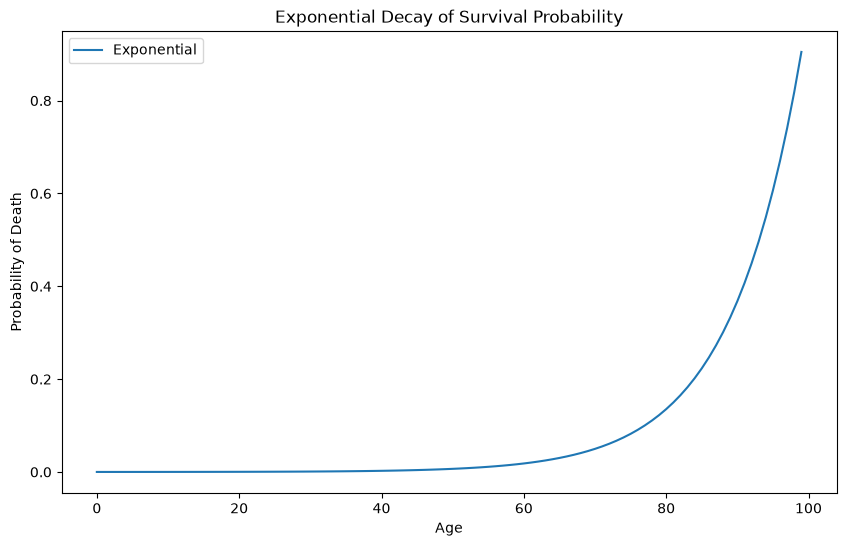

In [180]:
plot_exponential()